## Import Library & Load Data

In [1]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 75.2 MB/s eta 0:00:00


In [2]:
import os
import time
import zipfile
import platform
import numpy as np
import pandas as pd

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")

NB0_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook00"
NB2_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02"

CHUNK_SIZE = 100_000
COLS = ["t_s", "t_ns", "addr", "size", "entropy", "type"]
STORAGE_KINDS = ["ata_read", "ata_write"]
MEMORY_KINDS = ["mem_read", "mem_write", "mem_readwrite", "mem_exec"]
ALL_KINDS = STORAGE_KINDS + MEMORY_KINDS
CHECKPOINT_GRID_FULL = list(range(1, 31))

manifest = pd.read_csv(f"{NB0_DIR}/manifest.csv")
features_gold = pd.read_csv(f"{NB2_DIR}/features_gold.csv")
print(f"\nmanifest: {len(manifest)} baris | features_gold: {len(features_gold)} baris")

def find_payload(run_dir, kind):
    csv_path = os.path.join(run_dir, f"{kind}.csv")
    zip_path = os.path.join(run_dir, f"{kind}.zip")
    if os.path.exists(csv_path):
        return csv_path, "csv"
    if os.path.exists(zip_path):
        return zip_path, "zip"
    return None, None

def read_kind_until(run_dir, kind, max_t_rel, chunksize=CHUNK_SIZE):
    path, ext = find_payload(run_dir, kind)
    if path is None:
        return pd.DataFrame(columns=COLS + ["t_rel", "kind"])

    chunks = []
    state = {"t0": None}

    def consume(reader):
        for chunk in reader:
            if state["t0"] is None:
                state["t0"] = chunk["t_s"].iloc[0] + chunk["t_ns"].iloc[0] / 1e9
            chunk = chunk.assign(t_rel=(chunk["t_s"] + chunk["t_ns"] / 1e9) - state["t0"])
            chunks.append(chunk)
            if chunk["t_rel"].iloc[-1] > max_t_rel:
                break

    if ext == "csv":
        consume(pd.read_csv(path, header=None, names=COLS, chunksize=chunksize))
    else:
        with zipfile.ZipFile(path) as z:
            inner = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(inner) as f:
                consume(pd.read_csv(f, header=None, names=COLS, chunksize=chunksize))

    if not chunks:
        return pd.DataFrame(columns=COLS + ["t_rel", "kind"])
    df = pd.concat(chunks, ignore_index=True)
    df = df[df["t_rel"] <= max_t_rel].copy()
    df["kind"] = kind
    return df

class RunningStats:
    __slots__ = ["n", "sum_size", "sum_entropy", "mean_addr", "M2_addr", "count_by_type"]

    def __init__(self):
        self.n = 0
        self.sum_size = 0.0
        self.sum_entropy = 0.0
        self.mean_addr = 0.0
        self.M2_addr = 0.0
        self.count_by_type = {1: 0, 2: 0, 4: 0}

    def update(self, addr, size, entropy, type_):
        self.n += 1
        self.sum_size += size
        self.sum_entropy += entropy
        delta = addr - self.mean_addr
        self.mean_addr += delta / self.n
        delta2 = addr - self.mean_addr
        self.M2_addr += delta * delta2
        t = int(type_)
        if t in self.count_by_type:
            self.count_by_type[t] += 1

    def variance(self):
        return self.M2_addr / (self.n - 1) if self.n > 1 else 0.0

    def mean_entropy(self):
        return self.sum_entropy / self.n if self.n > 0 else 0.0

    def throughput(self, w):
        return self.sum_size / w


def snapshot_features(stats, w):
    r, wr = stats["ata_read"], stats["ata_write"]
    mr, mw, mrw, mx = stats["mem_read"], stats["mem_write"], stats["mem_readwrite"], stats["mem_exec"]
    feats = {
        "T_s_r": r.throughput(w), "T_s_w": wr.throughput(w),
        "V_s_r": r.variance(), "V_s_w": wr.variance(),
        "H_s_w": wr.mean_entropy(),
        "H_m_w": mw.mean_entropy(), "H_m_rw": mrw.mean_entropy(),
    }
    for label, type_val in [("4KB", 1), ("2MB", 2), ("MMIO", 4)]:
        for op_name, st in [("r", mr), ("w", mw), ("rw", mrw), ("x", mx)]:
            feats[f"C_{label}_{op_name}"] = st.count_by_type[type_val]
    for op_name, st in [("r", mr), ("w", mw), ("rw", mrw), ("x", mx)]:
        feats[f"V_m_{op_name}"] = st.variance()
    return feats


def stream_extract(run_dir, checkpoint_grid, max_w=30.0):
    dfs = [read_kind_until(run_dir, k, max_w) for k in ALL_KINDS]
    merged = pd.concat(dfs, ignore_index=True)
    merged = merged.sort_values("t_rel", kind="mergesort").reset_index(drop=True)

    stats = {k: RunningStats() for k in ALL_KINDS}
    grid_sorted = sorted(checkpoint_grid)
    grid_idx = 0
    snapshots = {}

    t0 = time.perf_counter()
    for row in merged.itertuples(index=False):
        while grid_idx < len(grid_sorted) and row.t_rel >= grid_sorted[grid_idx]:
            snapshots[grid_sorted[grid_idx]] = snapshot_features(stats, grid_sorted[grid_idx])
            grid_idx += 1
        stats[row.kind].update(row.addr, row.size, row.entropy, row.type)
    while grid_idx < len(grid_sorted):
        snapshots[grid_sorted[grid_idx]] = snapshot_features(stats, grid_sorted[grid_idx])
        grid_idx += 1
    elapsed = time.perf_counter() - t0

    return snapshots, len(merged), elapsed

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3

manifest: 1970 baris | features_gold: 59070 baris


## Validasi Ekstraktor Streaming terhadap features_gold.csv

In [3]:
N_SAMPLE_PER_CLASS = 2
RAW_MAX_W = 30.0

rng = np.random.default_rng(0)
original_valid = manifest[(manifest.group == "original") & (manifest.n_missing_kinds == 0)]
sample_paths = (original_valid.groupby("class", group_keys=False)
                .apply(lambda g: g.sample(min(N_SAMPLE_PER_CLASS, len(g)), random_state=0))["path"]
                .tolist())
print(f"Sampel validasi: {len(sample_paths)} eksekusi lintas {original_valid['class'].nunique()} kelas")

all_mismatches = []
n_compared_total = 0
rate_records = []

for path in sample_paths:
    gold_rows = features_gold[features_gold["path"] == path]
    if gold_rows.empty:
        print(f"  [LEWATI] {path}: tidak ada di features_gold.csv")
        continue
    checkpoints_here = sorted(gold_rows["window_s"].unique().tolist())

    snapshots, n_events, elapsed = stream_extract(path, checkpoints_here, max_w=RAW_MAX_W)
    rate_records.append({"path": path, "n_events": n_events, "elapsed_s": elapsed,
                          "events_per_sec": n_events / elapsed if elapsed > 0 else float("nan")})

    n_mismatch_here = 0
    for _, gold_row in gold_rows.iterrows():
        w = gold_row["window_s"]
        stream_feats = snapshots.get(w)
        if stream_feats is None:
            print(f"  [LEWATI] {path} w={w}: tidak ada snapshot streaming (event kosong di window ini?)")
            continue
        for key in stream_feats:
            b = gold_row[key]
            s = stream_feats[key]
            n_compared_total += 1
            if not np.isclose(b, s, rtol=1e-6, atol=1e-9):
                n_mismatch_here += 1
                all_mismatches.append((path, w, key, b, s))

    status = "LOLOS" if n_mismatch_here == 0 else f"GAGAL ({n_mismatch_here} mismatch)"
    print(f"  {path}: {n_events} event, {elapsed*1000:.1f} ms ({n_events/elapsed:,.0f} event/s) -- {status}")

print(f"\n RINGKASAN VALIDASI ")
print(f"Total nilai dibandingkan: {n_compared_total}")
print(f"Total mismatch (toleransi rtol=1e-6): {len(all_mismatches)}")
if all_mismatches:
    print("Rincian mismatch (maks 20 ditampilkan):")
    for path, w, key, b, s in all_mismatches[:20]:
        print(f"  {path} w={w} {key}: gold={b:.6f} stream={s:.6f} diff={abs(b-s):.2e}")
else:
    print("ekstraktor streaming identik dengan features_gold.csv pada seluruh sampel.")

rate_df = pd.DataFrame(rate_records)
rate_df.to_csv("/kaggle/working/nb9a_event_rate_sample.csv", index=False)
print(f"\n Estimasi laju event asli (dari {len(rate_df)} eksekusi sampel, tak terkendala) ")
print(rate_df[["path", "n_events", "elapsed_s", "events_per_sec"]].to_string(index=False))
print(f"\nRata-rata event/detik (median): {rate_df['events_per_sec'].median():,.0f}")
print(f"Rata-rata jumlah event per eksekusi (30 detik pertama): {rate_df['n_events'].mean():,.0f}")
print("Disimpan: /kaggle/working/nb9a_event_rate_sample.csv (dipakai NB9b sbg target throughput)")

Sampel validasi: 24 eksekusi lintas 12 kelas


/tmp/ipykernel_23/639735909.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(N_SAMPLE_PER_CLASS, len(g)), random_state=0))["path"]


  /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-2133-16g/AESCrypt/AESCrypt-20221005_11-26-27: 232504 event, 388.7 ms (598,110 event/s) -- LOLOS
  /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/i3-gen12/ddr4-2666-8g/AESCrypt/AESCrypt-20221208_20-54-42: 167462 event, 284.5 ms (588,589 event/s) -- LOLOS
  /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-2133-16g/Conti/Conti-20221006_15-21-39: 298400 event, 504.3 ms (591,702 event/s) -- LOLOS
  /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/i3-gen12/ddr4-2666-8g/Conti/Conti-20221117_20-46-31: 192720 event, 324.9 ms (593,110 event/s) -- LOLOS
  /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-2133-16g/Dark

## Setup Resource-Constrained

In [4]:
import json

NB4A_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook04b"
ONNX_DIR = f"{NB4A_DIR}/onnx_models"

with open(f"{NB4A_DIR}/nb4a_selected_hparams.json") as f:
    selected_params = json.load(f)

MODEL_NAMES = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]
CLASSICAL_MODELS = {"Decision Tree", "LightGBM", "XGBoost"}
DL_MODELS = {"TCN", "GRU", "CNN-LSTM"}

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]


def checkpoints_for_step(step, max_w=30):
    return list(range(step, max_w + 1, step))


ONNX_DIR_BY_MODEL = {name: ONNX_DIR for name in MODEL_NAMES}

print(f"Jumlah fitur: {len(FEATURE_COLUMNS_FULL)}")
print(f"Model: {MODEL_NAMES}")

Jumlah fitur: 24
Model: ['Decision Tree', 'LightGBM', 'XGBoost', 'TCN', 'GRU', 'CNN-LSTM']


## Mekanisme Pembatasan Resource (cpu_affinity + RLIMIT_AS adaptif + duty-cycle)

In [5]:
import multiprocessing as mp
import os
import resource
import signal
import threading
import time
import psutil


def duty_cycle_throttle(pid, duty_cycle_fraction, period_s, stop_event):
    run_time = period_s * duty_cycle_fraction
    stop_time = period_s * (1 - duty_cycle_fraction)
    while not stop_event.is_set():
        try:
            os.kill(pid, signal.SIGCONT)
        except ProcessLookupError:
            return
        if stop_event.wait(run_time):
            break
        try:
            os.kill(pid, signal.SIGSTOP)
        except ProcessLookupError:
            return
        if stop_event.wait(stop_time):
            break
    try:
        os.kill(pid, signal.SIGCONT)
    except ProcessLookupError:
        pass


def run_constrained(worker_fn, worker_args, cpu_cores=None, rlimit_buffer_mb=None,
                     duty_cycle_fraction=None, duty_cycle_period_s=0.05, timeout_s=60):
    q = mp.Queue()
    ready_event = mp.Event()
    p = mp.Process(target=worker_fn, args=(*worker_args, q, ready_event))
    p.start()

    child_proc = psutil.Process(p.pid)
    if cpu_cores is not None:
        child_proc.cpu_affinity(cpu_cores)
    if rlimit_buffer_mb is not None:
        parent_vms_mb = psutil.Process(os.getpid()).memory_info().vms / 1024 / 1024
        target_mb = parent_vms_mb + rlimit_buffer_mb
        _, hard = child_proc.rlimit(resource.RLIMIT_AS)
        child_proc.rlimit(resource.RLIMIT_AS, (int(target_mb * 1024 * 1024), hard))

    verified_affinity = child_proc.cpu_affinity()
    verified_rlimit = child_proc.rlimit(resource.RLIMIT_AS)[0]

    stop_event = threading.Event()
    throttle_thread = None
    if duty_cycle_fraction is not None:
        throttle_thread = threading.Thread(
            target=duty_cycle_throttle,
            args=(p.pid, duty_cycle_fraction, duty_cycle_period_s, stop_event),
            daemon=True,
        )
        throttle_thread.start()

    ready_event.set()
    wall_t0 = time.perf_counter()
    p.join(timeout=timeout_s)
    wall_elapsed = time.perf_counter() - wall_t0

    if throttle_thread is not None:
        stop_event.set()
        throttle_thread.join()

    if p.is_alive():
        p.terminate()
        p.join()
        status, detail = "TIMEOUT", None
    elif q.empty():
        status, detail = "MATI_TANPA_LAPOR", None
    else:
        status, detail = q.get()

    return {
        "status": status, "detail": detail, "wall_clock_s": wall_elapsed,
        "cpu_cores_verified": verified_affinity,
        "rlimit_as_verified_mb": verified_rlimit / 1024 / 1024 if verified_rlimit > 0 else None,
    }


def cpu_bound_worker(n_iterations, result_queue, ready_event):
    ready_event.wait()
    t0 = time.perf_counter()
    x = 0
    for i in range(n_iterations):
        x += i * i
    result_queue.put(("BERHASIL", round(time.perf_counter() - t0, 4)))

## Worker Gabungan: Ekstraksi Streaming + Inferensi ONNX per Checkpoint

In [6]:
import time
import numpy as np

def extract_positive_prob(onnx_output):
    prob_output = onnx_output[-1]
    if hasattr(prob_output, "shape"):
        arr = np.asarray(prob_output)
        if arr.ndim == 2 and arr.shape[1] >= 2:
            return float(arr[0, 1])
        return float(arr.flat[0])
    d = prob_output[0]
    if 1 in d:
        return float(d[1])
    if 1.0 in d:
        return float(d[1.0])
    return float(list(d.values())[-1])


def build_padded_input(feature_buffer, position, seq_len, n_features):
    arr = np.zeros((1, seq_len, n_features), dtype=np.float32)
    for j in range(position + 1):
        arr[0, j, :] = feature_buffer[j]
    return arr


def _process_checkpoint(w, grid_idx, stats, model_kind, sessions, feature_order,
                         feature_buffer, seq_len, n_features):
    t0 = time.perf_counter()
    feats_dict = snapshot_features(stats, w)
    feat_vec = np.array([feats_dict[k] if k != "w" else float(w) for k in feature_order],
                         dtype=np.float32)
    t_extract = time.perf_counter() - t0

    t1 = time.perf_counter()
    if model_kind == "classical":
        sess = sessions[grid_idx]
        inp_name = sess.get_inputs()[0].name
        out = sess.run(None, {inp_name: feat_vec.reshape(1, -1)})
        prob = extract_positive_prob(out)
    else:
        feature_buffer.append(feat_vec)
        inp_arr = build_padded_input(feature_buffer, grid_idx, seq_len, n_features)
        inp_name = sessions.get_inputs()[0].name
        out = sessions.run(None, {inp_name: inp_arr})[0]
        prob = float(out[0, grid_idx, 0])
    t_infer = time.perf_counter() - t1

    return {"window_s": w, "latency_extract_s": t_extract, "latency_infer_s": t_infer, "prob": prob}


def stream_extract_and_infer(run_dir, checkpoint_grid, model_kind, sessions, feature_order,
                              read_kind_until_fn, all_kinds_list, rss_sampler=None):
    dfs = [read_kind_until_fn(run_dir, k, max(checkpoint_grid)) for k in all_kinds_list]
    merged = pd.concat(dfs, ignore_index=True).sort_values("t_rel", kind="mergesort").reset_index(drop=True)

    stats = {k: RunningStats() for k in all_kinds_list}
    grid_sorted = sorted(checkpoint_grid)
    grid_idx = 0
    results = []
    feature_buffer = []
    seq_len = len(grid_sorted)
    n_features = len(feature_order)

    def _step(idx):
        r = _process_checkpoint(grid_sorted[idx], idx, stats, model_kind, sessions,
                                 feature_order, feature_buffer, seq_len, n_features)
        if rss_sampler is not None:
            r["rss_mb"] = rss_sampler()
        return r

    for row in merged.itertuples(index=False):
        while grid_idx < len(grid_sorted) and row.t_rel >= grid_sorted[grid_idx]:
            results.append(_step(grid_idx))
            grid_idx += 1
        stats[row.kind].update(row.addr, row.size, row.entropy, row.type)

    while grid_idx < len(grid_sorted):
        results.append(_step(grid_idx))
        grid_idx += 1

    return results, len(merged)

## Worker Lengkap: Muat Model ONNX (Nama File Dinormalisasi) + Jalankan di Bawah Batasan Resource

In [7]:
def constrained_model_worker(onnx_dir_path, model_name, model_kind, run_dir, checkpoint_grid,
                              feature_order, result_queue, ready_event):
    ready_event.wait()
    try:
        import os
        import re
        import time
        import onnxruntime as ort
        import psutil as _psutil

        def _normalize(s):
            return s.replace(" ", "_").replace("-", "_").lower()

        t_load0 = time.perf_counter()
        so = ort.SessionOptions()
        so.intra_op_num_threads = 1
        so.inter_op_num_threads = 1

        norm_model = _normalize(model_name)
        all_files = os.listdir(onnx_dir_path)

        if model_kind == "classical":
            files = [f for f in all_files if _normalize(f).startswith(norm_model + "_ckpt")]
            if not files:
                raise FileNotFoundError(
                    f"Tidak ada file cocok utk '{model_name}' (dinormalisasi: '{norm_model}_ckpt*') "
                    f"di {onnx_dir_path}. Isi folder: {sorted(all_files)[:20]}"
                )
            files_sorted = sorted(files, key=lambda f: int(re.search(r"ckpt(\d+)", f).group(1)))
            sessions = {i: ort.InferenceSession(os.path.join(onnx_dir_path, f), sess_options=so,
                                                 providers=["CPUExecutionProvider"])
                        for i, f in enumerate(files_sorted)}
        else:
            matches = [f for f in all_files if _normalize(f) == norm_model + ".onnx"]
            if not matches:
                raise FileNotFoundError(
                    f"Tidak ada file cocok utk '{model_name}' (dinormalisasi: '{norm_model}.onnx') "
                    f"di {onnx_dir_path}. Isi folder: {sorted(all_files)[:20]}"
                )
            sessions = ort.InferenceSession(os.path.join(onnx_dir_path, matches[0]), sess_options=so,
                                             providers=["CPUExecutionProvider"])
        t_load = time.perf_counter() - t_load0

        proc_self = _psutil.Process()
        mem_after_load_mb = proc_self.memory_info().rss / 1024**2
        rss_samples = [mem_after_load_mb]

        def _sample_rss():
            v = proc_self.memory_info().rss / 1024**2
            rss_samples.append(v)
            return v

        t_total0 = time.perf_counter()
        checkpoints, n_events = stream_extract_and_infer(
            run_dir, checkpoint_grid, model_kind, sessions, feature_order,
            read_kind_until, ALL_KINDS, rss_sampler=_sample_rss
        )
        t_total = time.perf_counter() - t_total0

        result_queue.put(("BERHASIL", {
            "load_time_s": t_load, "mem_after_load_mb": mem_after_load_mb,
            "peak_rss_mb": max(rss_samples), "total_extract_infer_s": t_total,
            "n_checkpoints": len(checkpoints), "n_events": n_events, "checkpoints": checkpoints,
        }))
    except MemoryError as e:
        result_queue.put(("MemoryError", str(e)))
    except Exception as e:
        import traceback
        result_queue.put((type(e).__name__, traceback.format_exc()))

## Harness Utama: 6 Model x 3 Tingkat x 5 Eksekusi Sampel (Resumable)

In [8]:
import os
import re

RESULTS_PATH = "/kaggle/working/nb9b_results.csv"
RESULT_COLUMNS = ["model", "tier", "path", "class_name", "status", "wall_clock_s", "load_time_s",
                   "peak_rss_mb", "total_extract_infer_s", "n_checkpoints", "n_events",
                   "mean_latency_extract_ms", "mean_latency_infer_ms", "error_detail"]

RLIMIT_BUFFER_MB = 512 
TIER_DEFS = {
    "unconstrained": dict(cpu_cores=None, rlimit_buffer_mb=None, duty_cycle_fraction=None, target_rss_mb=None),
    "wajar": dict(cpu_cores=[0], rlimit_buffer_mb=RLIMIT_BUFFER_MB, duty_cycle_fraction=None, target_rss_mb=300),
    "ketat": dict(cpu_cores=[0], rlimit_buffer_mb=RLIMIT_BUFFER_MB, duty_cycle_fraction=0.5, target_rss_mb=128),
}

CLASSICAL_MODELS = {"Decision Tree", "LightGBM", "XGBoost"}
DL_MODELS = {"TCN", "GRU", "CNN-LSTM"}


def load_done_keys():
    if os.path.exists(RESULTS_PATH):
        done = pd.read_csv(RESULTS_PATH)
        return set(zip(done["model"], done["tier"], done["path"]))
    return set()


def append_result(row):
    df_new = pd.DataFrame([row], columns=RESULT_COLUMNS)
    header = not os.path.exists(RESULTS_PATH)
    df_new.to_csv(RESULTS_PATH, mode="a", header=header, index=False)


def select_sample_executions(manifest_df, n_per_class_pool=1):
    target_classes = ["Idle", "WannaCry", "Conti", "Office", "SDelete"]
    original = manifest_df[(manifest_df.group == "original") & (manifest_df.n_missing_kinds == 0)]
    rows = []
    for cls in target_classes:
        pool = original[original["class"] == cls]
        if len(pool) == 0:
            continue
        rows.append(pool.sample(1, random_state=0).iloc[0])
    return pd.DataFrame(rows)[["path", "class"]].reset_index(drop=True)

def run_full_harness(model_names, sample_df, onnx_dir_by_model, selected_params, feature_order,
                      real_event_rate_per_s):
    done_keys = load_done_keys()
    total_combos = len(model_names) * len(TIER_DEFS) * len(sample_df)
    print(f"{len(done_keys)} dari {total_combos} kombinasi (model, tier, path) sudah selesai -- dilewati.\n")

    progress = 0
    for model_name in model_names:
        model_kind = "classical" if model_name in CLASSICAL_MODELS else "dl"
        grid = checkpoints_for_step(selected_params[model_name]["step"])
        onnx_dir = onnx_dir_by_model[model_name]

        for tier_name, tier_kwargs in TIER_DEFS.items():
            target_rss = tier_kwargs["target_rss_mb"]

            for _, samp in sample_df.iterrows():
                progress += 1
                key = (model_name, tier_name, samp["path"])
                if key in done_keys:
                    print(f"[SKIP {progress}/{total_combos}] {model_name} / {tier_name} / {samp['class']}")
                    continue

                r = run_constrained(
                    constrained_model_worker,
                    (onnx_dir, model_name, model_kind, samp["path"], grid, feature_order),
                    cpu_cores=tier_kwargs["cpu_cores"], rlimit_buffer_mb=tier_kwargs["rlimit_buffer_mb"],
                    duty_cycle_fraction=tier_kwargs["duty_cycle_fraction"], timeout_s=120,
                )

                row = {"model": model_name, "tier": tier_name, "path": samp["path"],
                       "class_name": samp["class"], "status": r["status"],
                       "wall_clock_s": r["wall_clock_s"]}
                if r["status"] == "BERHASIL":
                    d = r["detail"]
                    ckpts = d["checkpoints"]
                    row.update({
                        "load_time_s": d["load_time_s"], "peak_rss_mb": d["peak_rss_mb"],
                        "total_extract_infer_s": d["total_extract_infer_s"],
                        "n_checkpoints": d["n_checkpoints"], "n_events": d["n_events"],
                        "mean_latency_extract_ms": np.mean([c["latency_extract_s"] for c in ckpts]) * 1000,
                        "mean_latency_infer_ms": np.mean([c["latency_infer_s"] for c in ckpts]) * 1000,
                    })
                    lulus_rss = "-" if target_rss is None else ("LULUS" if d["peak_rss_mb"] <= target_rss else "GAGAL")
                    throughput = d["n_events"] / d["total_extract_infer_s"] if d["total_extract_infer_s"] > 0 else float("nan")
                    print(f"[{progress}/{total_combos}] {model_name:14s} {tier_name:14s} {samp['class']:10s} "
                          f"RSS={d['peak_rss_mb']:6.1f}MB (target<={target_rss}: {lulus_rss})  "
                          f"total={d['total_extract_infer_s']*1000:7.2f}ms  "
                          f"throughput={throughput:,.0f} event/s (target real-time>={real_event_rate_per_s:,.0f})")
                else:
                    row["error_detail"] = str(r["detail"])
                    for col in RESULT_COLUMNS:
                        row.setdefault(col, None)
                    print(f"[{progress}/{total_combos}] {model_name:14s} {tier_name:14s} {samp['class']:10s} "
                          f"GAGAL: {r['status']}")
                    print(f"  --- detail lengkap ---\n{r['detail']}\n  --- akhir detail ---")

                append_result(row)

    print(f"\nSelesai. Hasil di: {RESULTS_PATH}")


REAL_EVENT_RATE_PER_S = 6009 

sample_df = select_sample_executions(manifest)
print(" Sampel eksekusi terpilih (5 kelas, dipakai ulang utk semua model x tingkat) ")
print(sample_df.to_string(index=False))
print()

run_full_harness(MODEL_NAMES, sample_df, ONNX_DIR_BY_MODEL, selected_params, FEATURE_COLUMNS_FULL,
                  REAL_EVENT_RATE_PER_S)

 Sampel eksekusi terpilih (5 kelas, dipakai ulang utk semua model x tingkat) 
                                                                                                                                                                   path    class
        /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-2133-16g/Idle/Idle-20221019_11-48-57     Idle
/kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-2133-16g/WannaCry/WannaCry-20220928_14-04-07 WannaCry
      /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-2133-16g/Conti/Conti-20221006_15-21-39    Conti
    /kaggle/input/datasets/hiranomanabu/ransmap-2024-ransomware-behavioral-features/RanSMAP/dataset/original/celeron-gen6/ddr4-2133-16g/Office/Office-20221013_14-28-38   Office
  /kaggle/input/datasets/hiranomanabu

## Analisis Akhir: RSS, Throughput, %CPU Turunan

Total baris: 90 | BERHASIL: 90 | GAGAL: 0

 Ringkasan per model x tingkat (rata-rata atas eksekusi sampel) 

--- unconstrained ---
        model  peak_rss_mb  total_extract_infer_ms  throughput_event_per_s  cpu_pct_estimasi lulus_rss lulus_cpu_wajar
     CNN-LSTM       248.34                  637.98               288458.36              2.81         -               -
Decision Tree       246.31                  624.87               295435.97              2.77         -               -
          GRU       246.92                  625.91               294350.81              2.77         -               -
     LightGBM       246.40                  620.81               295724.93              2.74         -               -
          TCN       246.87                  635.32               290895.98              2.81         -               -
      XGBoost       249.93                  627.65               292328.49              2.77         -               -

--- wajar ---
        model  peak_r

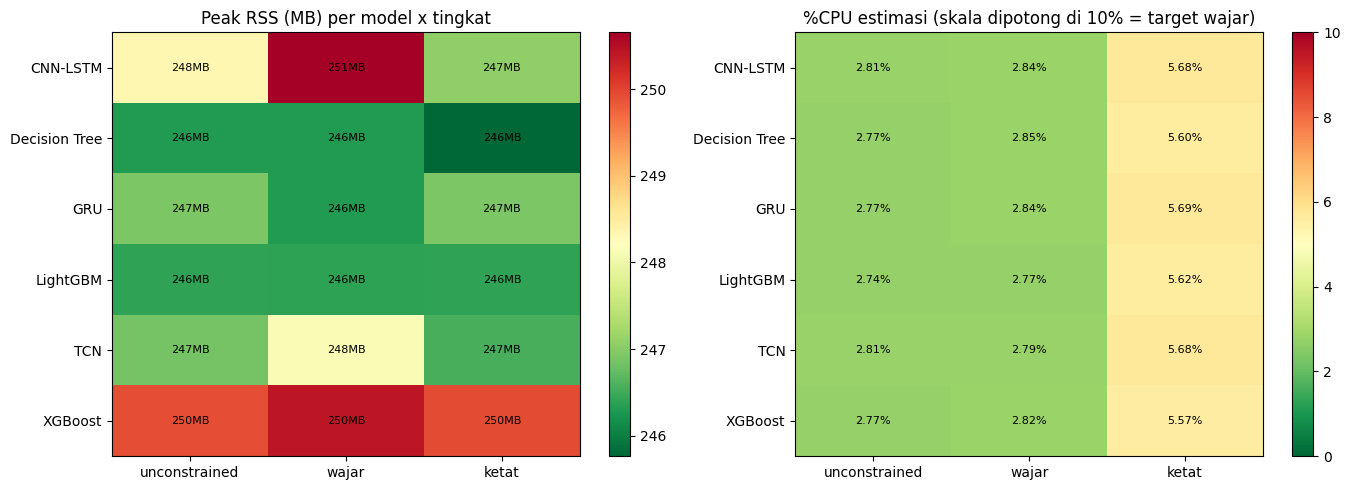


Ringkasan disimpan: /kaggle/working/nb9b_summary.csv
Heatmap disimpan: /kaggle/working/nb9b_summary_heatmap.png


In [9]:
import matplotlib.pyplot as plt

BITVISOR_OVERHEAD_PCT = 18.0 

results = pd.read_csv(RESULTS_PATH)
ok = results[results.status == "BERHASIL"].copy()
gagal = results[results.status != "BERHASIL"]

print(f"Total baris: {len(results)} | BERHASIL: {len(ok)} | GAGAL: {len(gagal)}")
if len(gagal) > 0:
    print("\n Kombinasi yang GAGAL ")
    print(gagal[["model", "tier", "class_name", "status"]].to_string(index=False))

ok["throughput_event_per_s"] = ok["n_events"] / ok["total_extract_infer_s"]
ok["cpu_pct_estimasi"] = (REAL_EVENT_RATE_PER_S / ok["throughput_event_per_s"]) * 100

TIER_TARGETS = {"unconstrained": None, "wajar": 300, "ketat": 128}
ok["target_rss_mb"] = ok["tier"].map(TIER_TARGETS)
ok["lulus_rss"] = ok.apply(
    lambda r: "-" if pd.isna(r["target_rss_mb"]) else ("LULUS" if r["peak_rss_mb"] <= r["target_rss_mb"] else "GAGAL"),
    axis=1
)
ok["lulus_cpu_wajar"] = ok.apply(
    lambda r: ("LULUS" if r["cpu_pct_estimasi"] <= 10.0 else "GAGAL") if r["tier"] == "wajar" else "-",
    axis=1
)

print("\n Ringkasan per model x tingkat (rata-rata atas eksekusi sampel) ")
summary = ok.groupby(["model", "tier"]).agg(
    peak_rss_mb=("peak_rss_mb", "mean"),
    total_extract_infer_ms=("total_extract_infer_s", lambda s: s.mean() * 1000),
    throughput_event_per_s=("throughput_event_per_s", "mean"),
    cpu_pct_estimasi=("cpu_pct_estimasi", "mean"),
).reset_index()
summary = summary.merge(ok[["model", "tier", "lulus_rss", "lulus_cpu_wajar"]].drop_duplicates(["model", "tier"]),
                         on=["model", "tier"])
for tier in ["unconstrained", "wajar", "ketat"]:
    print(f"\n--- {tier} ---")
    sub = summary[summary.tier == tier].sort_values("model")
    print(sub[["model", "peak_rss_mb", "total_extract_infer_ms", "throughput_event_per_s",
               "cpu_pct_estimasi", "lulus_rss", "lulus_cpu_wajar"]].round(2).to_string(index=False))

pivot_rss = summary.pivot(index="model", columns="tier", values="peak_rss_mb").reindex(
    columns=["unconstrained", "wajar", "ketat"]
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(pivot_rss.values, cmap="RdYlGn_r", aspect="auto")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(pivot_rss.columns)
axes[0].set_yticks(range(len(pivot_rss.index))); axes[0].set_yticklabels(pivot_rss.index)
for i in range(pivot_rss.shape[0]):
    for j in range(pivot_rss.shape[1]):
        axes[0].text(j, i, f"{pivot_rss.values[i,j]:.0f}MB", ha="center", va="center", fontsize=8)
axes[0].set_title("Peak RSS (MB) per model x tingkat")
fig.colorbar(im0, ax=axes[0])

pivot_cpu = summary.pivot(index="model", columns="tier", values="cpu_pct_estimasi").reindex(
    columns=["unconstrained", "wajar", "ketat"]
)
im1 = axes[1].imshow(pivot_cpu.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=10)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(pivot_cpu.columns)
axes[1].set_yticks(range(len(pivot_cpu.index))); axes[1].set_yticklabels(pivot_cpu.index)
for i in range(pivot_cpu.shape[0]):
    for j in range(pivot_cpu.shape[1]):
        axes[1].text(j, i, f"{pivot_cpu.values[i,j]:.2f}%", ha="center", va="center", fontsize=8)
axes[1].set_title("%CPU estimasi (skala dipotong di 10% = target wajar)")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig("/kaggle/working/nb9b_summary_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

summary.to_csv("/kaggle/working/nb9b_summary.csv", index=False)
print("\nRingkasan disimpan: /kaggle/working/nb9b_summary.csv")
print("Heatmap disimpan: /kaggle/working/nb9b_summary_heatmap.png")

In [10]:
import csv
import heapq
import io
import zipfile

def read_kind_streaming(run_dir, kind, max_t_rel):
    path, ext = find_payload(run_dir, kind)
    if path is None:
        return
    if ext == "csv":
        f = open(path, newline="")
    else:
        zf = zipfile.ZipFile(path)
        inner = [n for n in zf.namelist() if n.endswith(".csv")][0]
        f = io.TextIOWrapper(zf.open(inner), newline="")
    try:
        t0 = None
        for row in csv.reader(f):
            t_s, t_ns, addr, size, entropy, type_ = row
            t_abs = int(t_s) + int(t_ns) / 1e9
            if t0 is None:
                t0 = t_abs
            t_rel = t_abs - t0
            if t_rel > max_t_rel:
                break
            yield (t_rel, float(addr), float(size), float(entropy), int(float(type_)))
    finally:
        f.close()


KIND_ORDER_O1 = {k: i for i, k in enumerate(ALL_KINDS)}


def stream_extract_and_infer_o1(run_dir, checkpoint_grid, model_kind, sessions, feature_order,
                                 max_w=30.0, rss_sampler=None):
    gens = {k: read_kind_streaming(run_dir, k, max_w) for k in ALL_KINDS}
    heap = []
    row_counters = {k: 0 for k in ALL_KINDS}

    def _push(kind, gen):
        try:
            t_rel, addr, size, entropy, type_ = next(gen)
        except StopIteration:
            return
        tie = (KIND_ORDER_O1[kind], row_counters[kind])
        row_counters[kind] += 1
        heapq.heappush(heap, (t_rel, tie, kind, addr, size, entropy, type_, gen))

    for k, gen in gens.items():
        _push(k, gen)

    stats = {k: RunningStats() for k in ALL_KINDS}
    grid_sorted = sorted(checkpoint_grid)
    grid_idx = 0
    results = []
    feature_buffer = []
    seq_len = len(grid_sorted)
    n_features = len(feature_order)
    n_events = 0

    while heap:
        t_rel, tie, kind, addr, size, entropy, type_, gen = heapq.heappop(heap)
        while grid_idx < len(grid_sorted) and t_rel >= grid_sorted[grid_idx]:
            r = _process_checkpoint(grid_sorted[grid_idx], grid_idx, stats, model_kind, sessions,
                                     feature_order, feature_buffer, seq_len, n_features)
            if rss_sampler is not None:
                r["rss_mb"] = rss_sampler()
            results.append(r)
            grid_idx += 1
        stats[kind].update(addr, size, entropy, type_)
        n_events += 1
        _push(kind, gen)

    while grid_idx < len(grid_sorted):
        r = _process_checkpoint(grid_sorted[grid_idx], grid_idx, stats, model_kind, sessions,
                                 feature_order, feature_buffer, seq_len, n_features)
        if rss_sampler is not None:
            r["rss_mb"] = rss_sampler()
        results.append(r)
        grid_idx += 1

    return results, n_events

In [11]:
def constrained_model_worker_o1(onnx_dir_path, model_name, model_kind, run_dir, checkpoint_grid,
                                 feature_order, result_queue, ready_event):
    ready_event.wait()
    try:
        import os
        import re
        import time
        import onnxruntime as ort
        import psutil as _psutil

        def _normalize(s):
            return s.replace(" ", "_").replace("-", "_").lower()

        t_load0 = time.perf_counter()
        so = ort.SessionOptions()
        so.intra_op_num_threads = 1
        so.inter_op_num_threads = 1

        norm_model = _normalize(model_name)
        all_files = os.listdir(onnx_dir_path)

        if model_kind == "classical":
            files = [f for f in all_files if _normalize(f).startswith(norm_model + "_ckpt")]
            if not files:
                raise FileNotFoundError(
                    f"Tidak ada file cocok utk '{model_name}' di {onnx_dir_path}. "
                    f"Isi folder: {sorted(all_files)[:20]}"
                )
            files_sorted = sorted(files, key=lambda f: int(re.search(r"ckpt(\d+)", f).group(1)))
            sessions = {i: ort.InferenceSession(os.path.join(onnx_dir_path, f), sess_options=so,
                                                 providers=["CPUExecutionProvider"])
                        for i, f in enumerate(files_sorted)}
        else:
            matches = [f for f in all_files if _normalize(f) == norm_model + ".onnx"]
            if not matches:
                raise FileNotFoundError(
                    f"Tidak ada file cocok utk '{model_name}' di {onnx_dir_path}. "
                    f"Isi folder: {sorted(all_files)[:20]}"
                )
            sessions = ort.InferenceSession(os.path.join(onnx_dir_path, matches[0]), sess_options=so,
                                             providers=["CPUExecutionProvider"])
        t_load = time.perf_counter() - t_load0

        proc_self = _psutil.Process()
        mem_after_load_mb = proc_self.memory_info().rss / 1024**2
        rss_samples = [mem_after_load_mb]

        def _sample_rss():
            v = proc_self.memory_info().rss / 1024**2
            rss_samples.append(v)
            return v

        t_total0 = time.perf_counter()
        checkpoints, n_events = stream_extract_and_infer_o1(
            run_dir, checkpoint_grid, model_kind, sessions, feature_order,
            max_w=30.0, rss_sampler=_sample_rss
        )
        t_total = time.perf_counter() - t_total0

        result_queue.put(("BERHASIL", {
            "load_time_s": t_load, "mem_after_load_mb": mem_after_load_mb,
            "peak_rss_mb": max(rss_samples), "total_extract_infer_s": t_total,
            "n_checkpoints": len(checkpoints), "n_events": n_events, "checkpoints": checkpoints,
        }))
    except MemoryError as e:
        result_queue.put(("MemoryError", str(e)))
    except Exception as e:
        import traceback
        result_queue.put((type(e).__name__, traceback.format_exc()))

In [12]:
print(" Uji ulang tingkat 'ketat' pakai worker O(1) memory, label tier='ketat_o1' ")
done_keys_o1 = load_done_keys()
total_o1 = len(MODEL_NAMES) * len(sample_df)
progress_o1 = 0
for model_name in MODEL_NAMES:
    model_kind = "classical" if model_name in CLASSICAL_MODELS else "dl"
    grid = checkpoints_for_step(selected_params[model_name]["step"])
    onnx_dir = ONNX_DIR_BY_MODEL[model_name]
    for _, samp in sample_df.iterrows():
        progress_o1 += 1
        key = (model_name, "ketat_o1", samp["path"])
        if key in done_keys_o1:
            print(f"[SKIP {progress_o1}/{total_o1}] {model_name} / {samp['class']}")
            continue
        r = run_constrained(constrained_model_worker_o1,
                             (onnx_dir, model_name, model_kind, samp["path"], grid, FEATURE_COLUMNS_FULL),
                             cpu_cores=[0], rlimit_buffer_mb=512, duty_cycle_fraction=0.5, timeout_s=120)
        row = {"model": model_name, "tier": "ketat_o1", "path": samp["path"],
               "class_name": samp["class"], "status": r["status"], "wall_clock_s": r["wall_clock_s"]}
        if r["status"] == "BERHASIL":
            d = r["detail"]
            ckpts = d["checkpoints"]
            row.update({
                "load_time_s": d["load_time_s"], "peak_rss_mb": d["peak_rss_mb"],
                "total_extract_infer_s": d["total_extract_infer_s"],
                "n_checkpoints": d["n_checkpoints"], "n_events": d["n_events"],
                "mean_latency_extract_ms": np.mean([c["latency_extract_s"] for c in ckpts]) * 1000,
                "mean_latency_infer_ms": np.mean([c["latency_infer_s"] for c in ckpts]) * 1000,
            })
            lulus = "LULUS" if d["peak_rss_mb"] <= 128 else "GAGAL"
            print(f"[{progress_o1}/{total_o1}] {model_name:14s} {samp['class']:10s} "
                  f"RSS={d['peak_rss_mb']:6.1f}MB (target<=128: {lulus})  "
                  f"total={d['total_extract_infer_s']*1000:7.2f}ms")
        else:
            row["error_detail"] = str(r["detail"])
            for col in RESULT_COLUMNS:
                row.setdefault(col, None)
            print(f"[{progress_o1}/{total_o1}] {model_name:14s} {samp['class']:10s} GAGAL: {r['status']}")
            print(f"  --- detail ---\n{r['detail']}\n  --- akhir ---")
        append_result(row)
print(f"\nSelesai. Hasil ditambahkan ke: {RESULTS_PATH}")

 Uji ulang tingkat 'ketat' pakai worker O(1) memory, label tier='ketat_o1' 
[1/30] Decision Tree  Idle       RSS= 201.3MB (target<=128: GAGAL)  total= 615.93ms
[2/30] Decision Tree  WannaCry   RSS= 201.5MB (target<=128: GAGAL)  total=1606.66ms
[3/30] Decision Tree  Conti      RSS= 201.5MB (target<=128: GAGAL)  total=1669.80ms
[4/30] Decision Tree  Office     RSS= 201.5MB (target<=128: GAGAL)  total= 110.01ms
[5/30] Decision Tree  SDelete    RSS= 201.5MB (target<=128: GAGAL)  total=1870.99ms
[6/30] LightGBM       Idle       RSS= 201.6MB (target<=128: GAGAL)  total= 647.45ms
[7/30] LightGBM       WannaCry   RSS= 201.6MB (target<=128: GAGAL)  total=1606.09ms
[8/30] LightGBM       Conti      RSS= 201.7MB (target<=128: GAGAL)  total=1709.01ms
[9/30] LightGBM       Office     RSS= 201.7MB (target<=128: GAGAL)  total= 135.89ms
[10/30] LightGBM       SDelete    RSS= 201.7MB (target<=128: GAGAL)  total=1861.78ms
[11/30] XGBoost        Idle       RSS= 201.5MB (target<=128: GAGAL)  total= 619.57m